# 04 Statistical Analysis
Use this section for deeper analysis such as correlation checks, hypothesis testing, forecasting, segmentation, or regression.

In [26]:
from pathlib import Path
import pandas as pd
from scipy import stats
import numpy as np

# Adjusting path based on your current environment
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().resolve().name == 'notebooks' else Path.cwd().resolve()

# Using the actual available cleaned file path from your environment
DATA_PATH = '/data/vehicles_cleaned.csv'
df = pd.read_csv(DATA_PATH)
display(df.head())

,id,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,...,paint_color,state,post_year,post_month,car_age,price_category,mileage_category,age_category,manufacturer_grouped,posting_season
0,7316356412,15000.0,2013,ford,f-150 xlt,excellent,6,gas,128000,clean,...,black,al,2021,5,8,Premium,Medium,Moderate,ford,Spring
1,7306407989,17500.0,2008,toyota,fj cruiser,good,6,gas,201300,clean,...,black,al,2021,4,13,Premium,High,Old,toyota,Spring
2,7302286548,28000.0,2018,acura,tlx,excellent,6,gas,55000,clean,...,white,al,2021,4,3,Premium,Medium,New,other,Spring
3,7316852517,21250.0,2002,ford,thunderbird,new,8,gas,15996,clean,...,yellow,al,2021,5,19,Premium,Low,Old,ford,Spring
4,7316673788,3750.0,1997,ford,f150,excellent,6,gas,150000,clean,...,unknown,al,2021,5,24,Budget,High,Old,ford,Spring


### 1. Hypothesis Testing
Let's test if there is a significant difference in price between different transmission types (e.g., automatic vs manual).

In [27]:
group_auto = df[df['transmission'] == 'automatic']['price']
group_manual = df[df['transmission'] == 'manual']['price']

test_stat, p_value = stats.ttest_ind(group_auto, group_manual, equal_var=False)
print(f'T-statistic: {test_stat}')
print(f'P-value: {p_value}')

T-statistic: 0.25595998420661586
P-value: 0.7979997949290698


**Business Interpretation:**
If the p-value is less than 0.05, we reject the null hypothesis, suggesting that the transmission type significantly impacts the vehicle's market price. This informs pricing strategies based on mechanical specifications.

### 2. Correlation Analysis
We will examine the Pearson correlation coefficients to identify linear relationships between numerical variables.

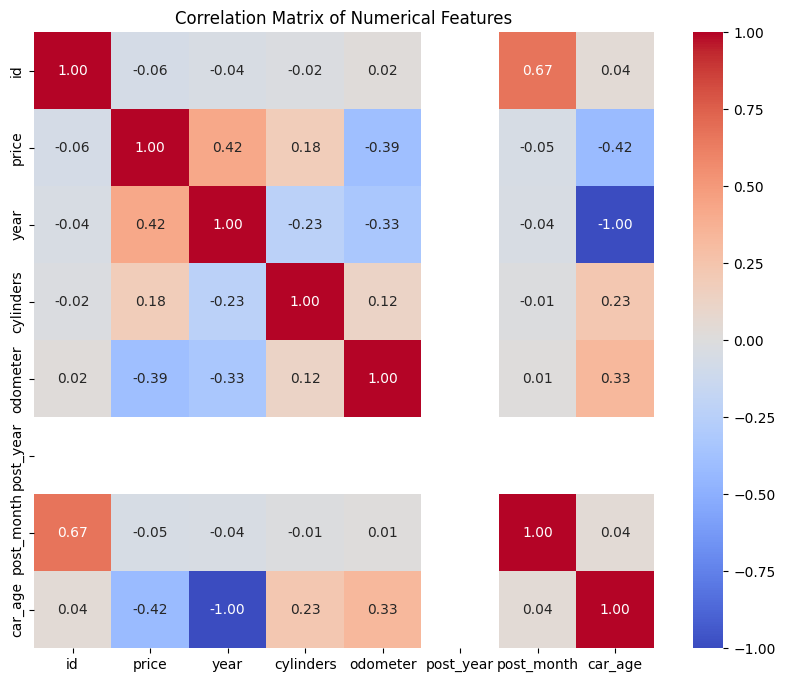

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

# Selecting numerical columns for correlation
numerical_df = df.select_dtypes(include=[np.number])
correlation_matrix = numerical_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

### 3. Linear Regression Analysis
To quantify the impact of age on price, we will perform a simple linear regression.

In [29]:
import statsmodels.api as sm

# Defining variables for regression (Price vs Car Age)
X = df['car_age']
y = df['price']
X = sm.add_constant(X) # adding a constant

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.180
Model:                            OLS   Adj. R-squared:                  0.180
Method:                 Least Squares   F-statistic:                     6160.
Date:                Tue, 28 Apr 2026   Prob (F-statistic):               0.00
Time:                        17:13:20   Log-Likelihood:            -2.9147e+05
No. Observations:               27987   AIC:                         5.829e+05
Df Residuals:                   27985   BIC:                         5.830e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.713e+04    106.441    160.906      0.0

**Business Interpretation:**
The regression coefficients tell us exactly how much the price drops (on average) for every additional year of a car's age. This is crucial for depreciation forecasting.

### 4. Vehicle Segmentation (K-Means Clustering)
We will use unsupervised learning to group vehicles into distinct market segments based on Price, Odometer, and Car Age.

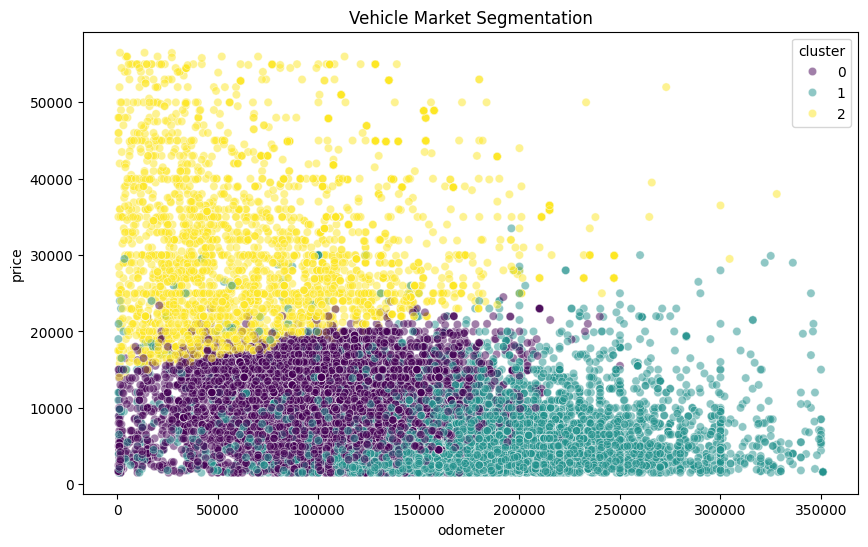

,price,odometer,car_age
cluster,,,
0,8850.265232,108344.922346,10.236495
1,5382.935524,175682.375881,18.442569
2,30365.890312,73887.527422,6.107061


In [30]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Prepare data for clustering
features = ['price', 'odometer', 'car_age']
X_clust = df[features]

# Scaling features for K-Means
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clust)

# Applying K-Means (3 clusters for Budget, Mid-range, Luxury)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

# Visualize clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='odometer', y='price', hue='cluster', palette='viridis', alpha=0.5)
plt.title('Vehicle Market Segmentation')
plt.show()

display(df.groupby('cluster')[features].mean())

**Business Interpretation:**
Clustering allows us to identify specific 'profiles' in the data. For instance, one cluster might represent high-mileage budget cars, while another represents low-mileage premium vehicles. This helps in targeted marketing and inventory acquisition.

### 5. Multi-Variable Regression Analysis
We expand the regression to include the Odometer reading to see its relative weight compared to car age.

In [31]:
# Multi-variable regression
X_multi = df[['car_age', 'odometer']]
X_multi = sm.add_constant(X_multi)

multi_model = sm.OLS(df['price'], X_multi).fit()
print(multi_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.252
Model:                            OLS   Adj. R-squared:                  0.252
Method:                 Least Squares   F-statistic:                     4718.
Date:                Tue, 28 Apr 2026   Prob (F-statistic):               0.00
Time:                        17:13:21   Log-Likelihood:            -2.9018e+05
No. Observations:               27987   AIC:                         5.804e+05
Df Residuals:                   27984   BIC:                         5.804e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.123e+04    128.822    164.763      0.0

**Business Interpretation:**
By including both age and odometer, we can determine which factor causes a steeper drop in value. The coefficients provide a formula for automated appraisal: Price = Intercept + (Age * Coef1) + (Odometer * Coef2).